In [1]:
# import core packages
import pandas as pd
import numpy as np
import os
import snowflake.connector as snow
import pyreadstat
import xlsxwriter
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import NamedStyle

# see all columns
pd.set_option('display.max_columns', None)

# define enviro variables
user = os.environ['USER']
username = os.environ["SNOWFLAKE_USER"]
sf_pass = os.environ["SNOWFLAKE_PASSWORD"]

# set working directory
os.chdir(f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/Shared drives/Insights")
# see all columns
pd.set_option('display.max_columns', None)

# establish snowflake connection
conn = snow.connect(
    user=username,
    password=sf_pass,
    account='avb99459.us-east-1',
    warehouse='OPPORTUNITYATWORK_WH',
    role='PUBLIC'
)

cur = conn.cursor()

In [2]:
# read JOLTS job openings data
JOLTS_openings = pd.read_excel(
    f"/Users/{user}/Documents/USF/ECON696/updated code/SeriesReport-20260401125728_e88978.xlsx",
    sheet_name="BLS Data Series",
    skiprows=13,
    nrows=11
)

JOLTS_openings

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,2016,5894,5549,6058.0,6362.0,5773.0,5624.0,6407.0,5854.0,5962.0,5972.0,5536.0,5287.0
1,2017,5529,5670,5742.0,6647.0,5839.0,6219.0,6658.0,6467.0,6439.0,6683.0,5832.0,5683.0
2,2018,6568,6269,6744.0,7410.0,7015.0,7195.0,7609.0,7436.0,7504.0,7665.0,7086.0,6744.0
3,2019,7442,6756,7257.0,7772.0,7284.0,7181.0,7433.0,7410.0,7231.0,7652.0,6428.0,6034.0
4,2020,7102,6657,5731.0,5166.0,5403.0,5991.0,7230.0,6589.0,6630.0,7346.0,6321.0,6129.0
5,2021,7124,7418,8355.0,9939.0,9721.0,10071.0,11954.0,11077.0,10969.0,11967.0,10515.0,10694.0
6,2022,11281,11209,12029.0,12607.0,11206.0,10907.0,12616.0,10157.0,10827.0,11089.0,10030.0,10182.0
7,2023,10442,9500,9510.0,10672.0,9126.0,8899.0,9401.0,9267.0,9235.0,9047.0,8164.0,7947.0
8,2024,8561,8143,8066.0,8119.0,7584.0,7195.0,7999.0,7536.0,6913.0,7754.0,7254.0,6798.0
9,2025,7612,7008,6807.0,7667.0,7104.0,6982.0,7586.0,6952.0,7136.0,7540.0,6591.0,6088.0


In [3]:
# reshape to long format
JOLTS_long = (
    JOLTS_openings
    .melt(id_vars="Year", var_name="month_str", value_name="job_openings")
    .dropna(subset=["job_openings"])
    .assign(
        month=lambda x: pd.to_datetime(x["month_str"], format="%b").dt.month,
        year_month=lambda x: pd.to_datetime(x["Year"].astype(int).astype(str) + "-" + x["month"].astype(str), format="%Y-%m")
    )
    .sort_values("year_month")
    .reset_index(drop=True)
    [["year_month", "job_openings"]]
)

JOLTS_long

,year_month,job_openings
0,2016-01-01,5894.0
1,2016-02-01,5549.0
2,2016-03-01,6058.0
3,2016-04-01,6362.0
4,2016-05-01,5773.0
...,...,...
117,2025-10-01,7540.0
118,2025-11-01,6591.0
119,2025-12-01,6088.0
120,2026-01-01,7377.0


In [4]:
JOLTS_long = JOLTS_long[
    (JOLTS_long["year_month"] >= "2020-01") &
    (JOLTS_long["year_month"] <= "2025-12")
]

JOLTS_long

,year_month,job_openings
48,2020-01-01,7102.0
49,2020-02-01,6657.0
50,2020-03-01,5731.0
51,2020-04-01,5166.0
52,2020-05-01,5403.0
...,...,...
115,2025-08-01,6952.0
116,2025-09-01,7136.0
117,2025-10-01,7540.0
118,2025-11-01,6591.0


### Monthly Lightcast Postings (Active Window)

Counts postings active in each month — a posting is included in every month between its `posted` and `expired` dates, not just when it first appeared. Matches Lightcast Analyst's methodology.

In [5]:
query = f'''
with months as (
    select
        dateadd('month', row_number() over (order by seq4()) - 1, '2020-01-01')::date as year_month
    from table(generator(rowcount => 72))
    qualify year_month <= '2025-12-01'
)
select
    m.year_month,
    year(m.year_month) as year,
    month(m.year_month) as month,
    count(distinct p.id) as total_postings
from months m
inner join emsi.us.postings p
    on p.posted  <= last_day(m.year_month)
    and p.expired >= m.year_month
group by all
order by m.year_month
'''

cur = conn.cursor().execute(query)
lightcast_monthly = pd.DataFrame.from_records(
    iter(cur),
    columns=[x[0] for x in cur.description]
)

lightcast_monthly.columns = lightcast_monthly.columns.str.lower()
lightcast_monthly.head()

,year_month,year,month,total_postings
0,2020-01-01,2020,1,8833678
1,2020-02-01,2020,2,9055091
2,2020-03-01,2020,3,9499669
3,2020-04-01,2020,4,8213650
4,2020-05-01,2020,5,7599313


In [6]:
lightcast_monthly.head(5)

,year_month,year,month,total_postings
0,2020-01-01,2020,1,8833678
1,2020-02-01,2020,2,9055091
2,2020-03-01,2020,3,9499669
3,2020-04-01,2020,4,8213650
4,2020-05-01,2020,5,7599313


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# align dtypes and merge
lightcast_monthly["year_month"] = pd.to_datetime(lightcast_monthly["year_month"])
JOLTS_long["year_month"] = pd.to_datetime(JOLTS_long["year_month"])

merged = lightcast_monthly.merge(JOLTS_long, on="year_month", how="inner")
merged.head()

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_98326/2692245806.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  JOLTS_long["year_month"] = pd.to_datetime(JOLTS_long["year_month"])


,year_month,year,month,total_postings,job_openings
0,2020-01-01,2020,1,8833678,7102.0
1,2020-02-01,2020,2,9055091,6657.0
2,2020-03-01,2020,3,9499669,5731.0
3,2020-04-01,2020,4,8213650,5166.0
4,2020-05-01,2020,5,7599313,5403.0


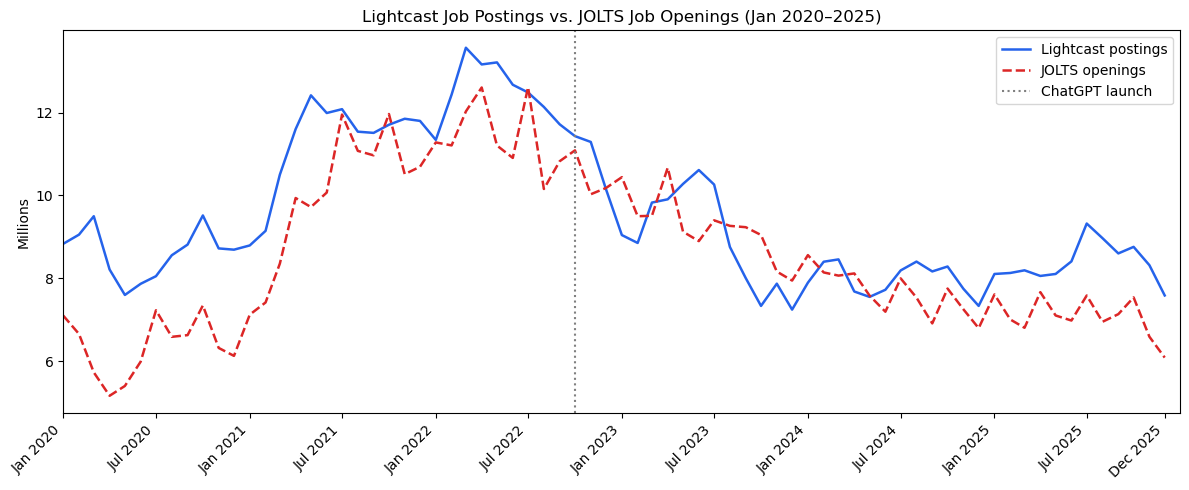

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(merged["year_month"], merged["total_postings"] / 1e6,
        color="#2563eb", linewidth=1.8, label="Lightcast postings")
ax.plot(merged["year_month"], merged["job_openings"] / 1e3,
        color="#dc2626", linewidth=1.8, linestyle="--", label="JOLTS openings")

ax.axvline(pd.Timestamp("2022-10-01"), color="gray", linestyle=":", linewidth=1.5, label="ChatGPT launch")

# explicit ticks: Jan and Jul each year, plus Dec 2025 at the end
ticks = pd.date_range("2020-01-01", "2025-07-01", freq="6MS").append(
    pd.DatetimeIndex(["2025-12-01"])
)
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2025-12-31"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.set_ylabel("Millions")
ax.set_title("Lightcast Job Postings vs. JOLTS Job Openings (Jan 2020–2025)")
ax.legend()
plt.tight_layout()
plt.savefig("/Users/khaliun/Documents/USF/ECON696/slide_figures/jolts_validation.png", dpi=150, bbox_inches="tight")
plt.show()

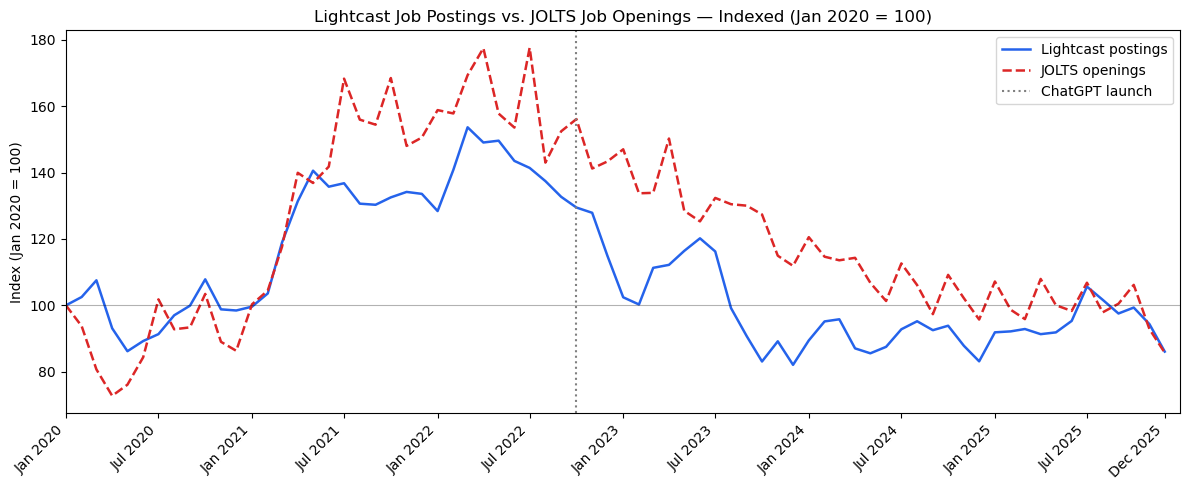

In [74]:
# index both series to Jan 2020 = 100
base = merged[merged["year_month"] == "2020-01-01"].iloc[0]
merged["lightcast_idx"] = merged["total_postings"] / base["total_postings"] * 100
merged["jolts_idx"]     = merged["job_openings"]   / base["job_openings"]   * 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(merged["year_month"], merged["lightcast_idx"],
        color="#2563eb", linewidth=1.8, label="Lightcast postings")
ax.plot(merged["year_month"], merged["jolts_idx"],
        color="#dc2626", linewidth=1.8, linestyle="--", label="JOLTS openings")

ax.axvline(pd.Timestamp("2022-10-01"), color="gray", linestyle=":", linewidth=1.5, label="ChatGPT launch")
ax.axhline(100, color="black", linewidth=0.8, alpha=0.3)

# explicit ticks: Jan and Jul each year, plus Dec 2025 at the end
ticks = pd.date_range("2020-01-01", "2025-07-01", freq="6MS").append(
    pd.DatetimeIndex(["2025-12-01"])
)
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2025-12-31"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax.set_ylabel("Index (Jan 2020 = 100)")
ax.set_title("Lightcast Job Postings vs. JOLTS Job Openings — Indexed (Jan 2020 = 100)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Figure 2: Distribution of Occupation-Level Job Posting Changes (2015–2025)

This figure constructs a distribution of posting growth rates across occupations to define what constitutes a meaningful **downward demand shock** — occupations that saw an unusually large and sustained drop in hiring demand. The output is used as a control variable in the main DiD regression to ensure the AI effect is not confounded by broader sector-level demand declines.

**Steps:**

1. **Pull monthly posting counts by occupation** — Query Lightcast (EMSI) for the number of job postings per SOC 5-digit occupation per month, using the *posted date* (2015–2025). Posted date captures when new demand originated, not how long postings were live.

2. **Check for sparse occupations** — Build a full 132-month spine (Jan 2015–Dec 2025) and identify occupations with missing months. Missing = zero postings in that month, which Snowflake omits entirely.

3. **Drop thin occupations** — Remove occupations in the bottom 5% by average monthly posting volume and require a minimum of 100 average postings per month. This excludes rare/niche occupations too small to produce reliable growth rate estimates.

4. **Compute rolling % changes** — Within each occupation, calculate the 6-month and 12-month percent change in postings using `.pct_change()`. The 12-month measure is preferred because it automatically removes seasonal variation (comparing the same month across years).

5. **Plot the distributions** — Show histograms of these % changes across all occupation-months, clipped at -100%/+200% for readability. The p10 and p25 thresholds are marked to inform where to draw the shock cutoff. Shown twice: once for the full period and once excluding 2020–2022 (COVID years) to check whether the shock distribution is driven by pandemic-era swings.

6. **Define the shock variable** — For each occupation, average its 12-month % change over the post-ChatGPT period (Oct 2022–Dec 2025) to produce one number per occupation (`avg_demand_change_post`). Flag as `demand_shock = 1` if this average falls below the p10 of the full distribution.

In [75]:
# monthly postings by occupation (posted date)
query_occ = f'''
select
    date_trunc('month', p.posted)::date as year_month,
    year(p.posted) as year,
    month(p.posted) as month,
    p.soc_2021_5,
    p.soc_2021_5_name,
    count(distinct p.id) as total_postings
from emsi.us.postings p
where year(p.posted) between 2015 and 2025
group by all
order by p.soc_2021_5, year_month
'''

cur_occ = conn.cursor().execute(query_occ)
occ_monthly = pd.DataFrame.from_records(
    iter(cur_occ),
    columns=[x[0] for x in cur_occ.description]
)
occ_monthly.columns = occ_monthly.columns.str.lower()
occ_monthly['year_month'] = pd.to_datetime(occ_monthly['year_month'])
print(occ_monthly.shape)
occ_monthly.head()

(99631, 6)


,year_month,year,month,soc_2021_5,soc_2021_5_name,total_postings
0,2015-01-01,2015,1,11-1011,Chief Executives,4254
1,2015-02-01,2015,2,11-1011,Chief Executives,3568
2,2015-03-01,2015,3,11-1011,Chief Executives,3963
3,2015-04-01,2015,4,11-1011,Chief Executives,4048
4,2015-05-01,2015,5,11-1011,Chief Executives,4465


In [76]:
# check for gaps in the monthly series per occupation
full_months = pd.date_range('2015-01-01', '2025-12-01', freq='MS')
n_months = len(full_months)
all_occs = occ_monthly['soc_2021_5'].unique()

expected = n_months * len(all_occs)
actual   = len(occ_monthly)
missing  = expected - actual

print(f'Occupations:          {len(all_occs):,}')
print(f'Months in spine:      {n_months}')
print(f'Expected occ-months:  {expected:,}')
print(f'Actual occ-months:    {actual:,}')
print(f'Missing occ-months:   {missing:,}  ({missing/expected*100:.1f}%)')
print()

occ_counts = (
    occ_monthly.groupby('soc_2021_5')['year_month']
    .count()
    .to_frame(name='months_present')
)
occ_counts['months_missing'] = n_months - occ_counts['months_present']

print(f'Occupations with complete series ({n_months} months):  ', (occ_counts['months_present'] == n_months).sum())
print('Occupations with 1+ missing months:             ', (occ_counts['months_missing'] > 0).sum())
print()
print('Distribution of missing months per occupation:')
print(occ_counts['months_missing'].describe().round(1))

Occupations:          768
Months in spine:      132
Expected occ-months:  101,376
Actual occ-months:    99,631
Missing occ-months:   1,745  (1.7%)

Occupations with complete series (132 months):   706
Occupations with 1+ missing months:              62

Distribution of missing months per occupation:
count    768.0
mean       2.3
std       11.9
min        0.0
25%        0.0
50%        0.0
75%        0.0
max      131.0
Name: months_missing, dtype: float64


In [77]:
# show occupations with at least one missing month
missing_occs = occ_counts[occ_counts['months_missing'] > 0].index

(
    occ_monthly[occ_monthly['soc_2021_5'].isin(missing_occs)]
    [['soc_2021_5', 'soc_2021_5_name']]
    .drop_duplicates()
    .merge(occ_counts[['months_present', 'months_missing']], on='soc_2021_5')
    .sort_values('months_missing', ascending=False)
    .reset_index(drop=True)
)


,soc_2021_5,soc_2021_5_name,months_present,months_missing
0,53-7071,Gas Compressor and Gas Pumping Station Operators,1,131
1,47-2082,Tapers,14,118
2,53-7011,Conveyor Operators and Tenders,15,117
3,53-1041,Aircraft Cargo Handling Supervisors,40,92
4,15-2099,"Mathematical Science Occupations, All Other",40,92
...,...,...,...,...
57,49-9097,Signal and Track Switch Repairers,131,1
58,51-9021,"Crushing, Grinding, and Polishing Machine Sett...",131,1
59,51-4081,"Multiple Machine Tool Setters, Operators, and ...",131,1
60,53-5022,Motorboat Operators,131,1


In [78]:
# compute average monthly postings per occupation across full sample
occ_avg = (
    occ_monthly.groupby('soc_2021_5')['total_postings']
    .mean()
    .rename('avg_monthly_postings')
    .reset_index()
)

# drop bottom 5% by average posting volume, and require >= 100 postings/month
p5 = occ_avg['avg_monthly_postings'].quantile(0.05)
threshold = max(p5, 100)
print(f'Bottom 5% threshold:  {p5:.0f} avg postings/month')
print(f'Effective threshold:  {threshold:.0f} avg postings/month')

keep_occs = occ_avg[occ_avg['avg_monthly_postings'] >= threshold]['soc_2021_5']
occ_monthly = occ_monthly[occ_monthly['soc_2021_5'].isin(keep_occs)].reset_index(drop=True)

print(f'Occupations kept:    {occ_monthly["soc_2021_5"].nunique()}')
print(f'Occ-months:          {len(occ_monthly):,}')

Bottom 5% threshold:  6 avg postings/month
Effective threshold:  100 avg postings/month
Occupations kept:    634
Occ-months:          83,688


In [79]:
# compute 6-month and 12-month % change within each occupation
occ_monthly = occ_monthly.sort_values(['soc_2021_5', 'year_month'])

occ_monthly['pct_change_6m'] = (
    occ_monthly.groupby('soc_2021_5')['total_postings']
    .pct_change(periods=6) * 100
)
occ_monthly['pct_change_12m'] = (
    occ_monthly.groupby('soc_2021_5')['total_postings']
    .pct_change(periods=12) * 100
)

occ_monthly[['soc_2021_5', 'year_month', 'total_postings', 'pct_change_6m', 'pct_change_12m']].head(20)

,soc_2021_5,year_month,total_postings,pct_change_6m,pct_change_12m
0,11-1011,2015-01-01,4254,NaN,NaN
1,11-1011,2015-02-01,3568,NaN,NaN
2,11-1011,2015-03-01,3963,NaN,NaN
3,11-1011,2015-04-01,4048,NaN,NaN
4,11-1011,2015-05-01,4465,NaN,NaN
5,11-1011,2015-06-01,5151,NaN,NaN
6,11-1011,2015-07-01,4840,13.775270,NaN
7,11-1011,2015-08-01,4878,36.715247,NaN
8,11-1011,2015-09-01,4410,11.279334,NaN
9,11-1011,2015-10-01,4233,4.570158,NaN


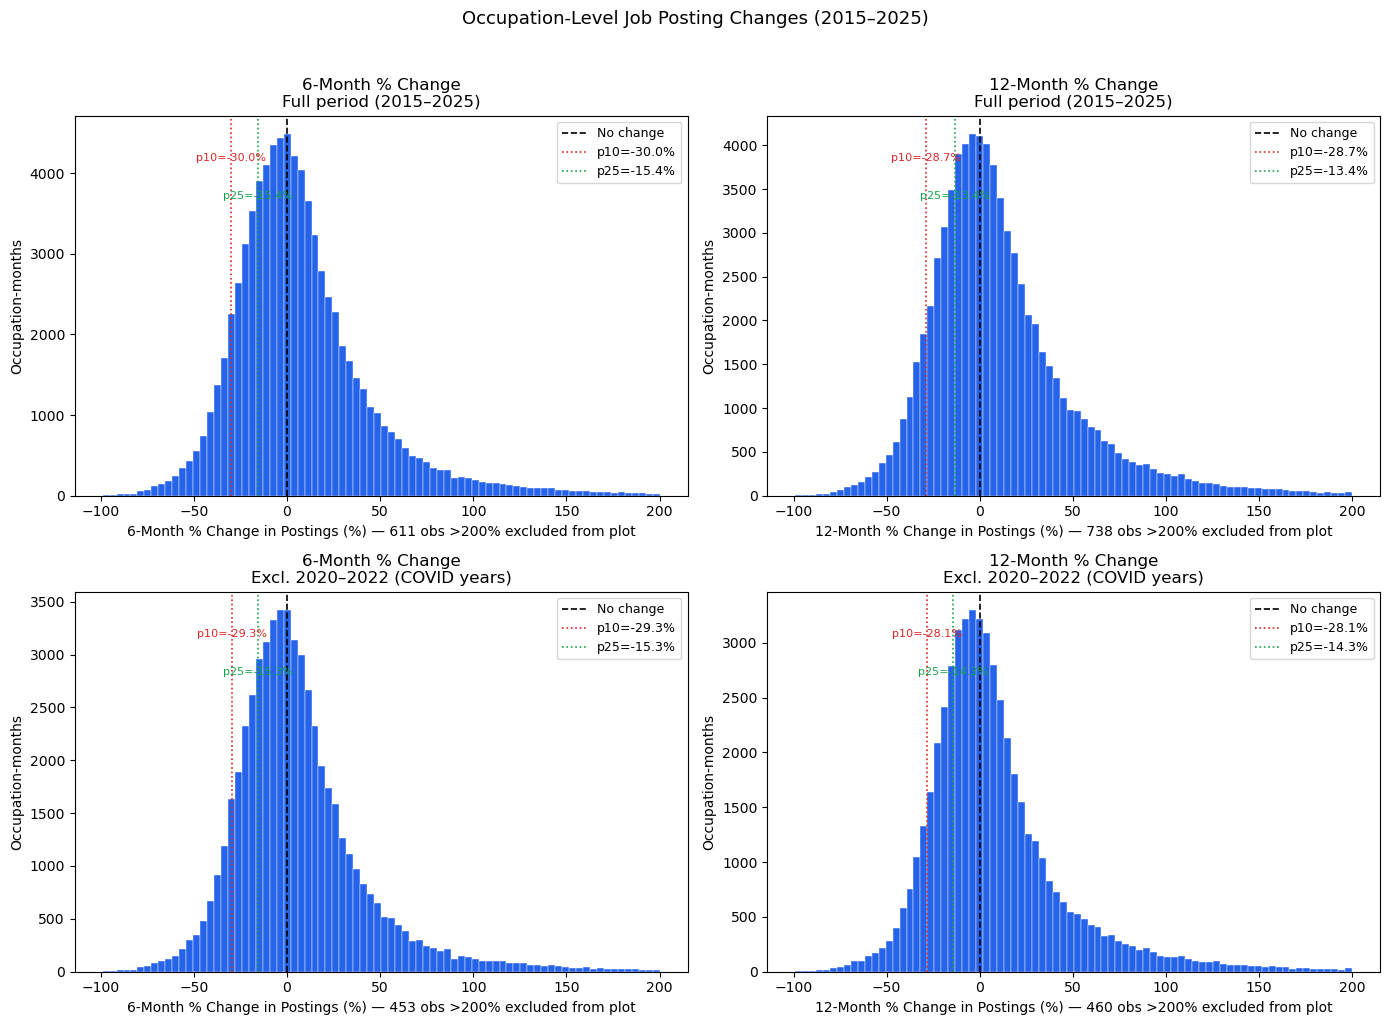

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

periods = [
    ('Full period (2015–2025)',       occ_monthly['year_month'].dt.year.between(2015, 2025)),
    ('Excl. 2020–2022 (COVID years)', ~occ_monthly['year_month'].dt.year.between(2020, 2022)),
]

for row, (period_label, mask) in enumerate(periods):
    for col, (col_name, xlabel) in enumerate([
        ('pct_change_6m',  '6-Month % Change'),
        ('pct_change_12m', '12-Month % Change'),
    ]):
        ax = axes[row][col]
        data_all  = occ_monthly[mask][col_name].dropna()   # all obs — for p10/p25 stats
        data_plot = data_all[data_all <= 200]               # drop >200% for graph only

        ax.hist(data_plot, bins=80, color='#2563eb', edgecolor='white', linewidth=0.3)
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='No change')

        p10 = data_all.quantile(0.10)   # from full distribution
        p25 = data_all.quantile(0.25)
        ax.axvline(p10, color='#dc2626', linewidth=1.2, linestyle=':', label=f'p10={p10:.1f}%')
        ax.axvline(p25, color='#16a34a', linewidth=1.2, linestyle=':', label=f'p25={p25:.1f}%')

        ymax = ax.get_ylim()[1]
        ax.text(p10, ymax * 0.88, f'p10={p10:.1f}%', color='#dc2626', fontsize=8, ha='center')
        ax.text(p25, ymax * 0.78, f'p25={p25:.1f}%', color='#16a34a', fontsize=8, ha='center')

        n_dropped = (data_all > 200).sum()
        ax.set_xlabel(f'{xlabel} in Postings (%) — {n_dropped:,} obs >200% excluded from plot')
        ax.set_ylabel('Occupation-months')
        ax.set_title(f'{xlabel}\n{period_label}')
        ax.legend(fontsize=9)

plt.suptitle('Occupation-Level Job Posting Changes (2015–2025)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [81]:
# construct occupation-level demand shock measure
# = average 12-month % change in the post-period (Oct 2022 - Dec 2025)
# this captures whether the occupation had a broad demand decline post-ChatGPT

post_changes = (
    occ_monthly[occ_monthly['year_month'] >= '2022-10-01']
    .groupby(['soc_2021_5', 'soc_2021_5_name'])['pct_change_12m']
    .mean()
    .reset_index()
    .rename(columns={'pct_change_12m': 'avg_demand_change_post'})
)

# flag shocks below p10 of full 12m distribution
p10_threshold = occ_monthly['pct_change_12m'].quantile(0.10)
print(f'p10 threshold (12m): {p10_threshold:.1f}%')

post_changes['demand_shock'] = (post_changes['avg_demand_change_post'] < p10_threshold).astype(int)

print(f'Occupations flagged as demand shock: {post_changes["demand_shock"].sum()} / {len(post_changes)}')
post_changes.sort_values('avg_demand_change_post').head(15)

p10 threshold (12m): -28.7%
Occupations flagged as demand shock: 0 / 634


,soc_2021_5,soc_2021_5_name,avg_demand_change_post,demand_shock
79,15-1254,Web Developers,-26.355438,0
376,39-3092,Costume Attendants,-22.720378,0
452,43-9021,Data Entry Keyers,-20.418750,0
428,43-4071,File Clerks,-19.962742,0
204,27-1013,"Fine Artists, Including Painters, Sculptors, a...",-18.990855,0
120,19-1021,Biochemists and Biophysicists,-18.945002,0
76,15-1251,Computer Programmers,-18.756106,0
80,15-1255,Web and Digital Interface Designers,-18.174997,0
628,53-7064,"Packers and Packagers, Hand",-17.894154,0
42,13-1071,Human Resources Specialists,-17.801520,0


Correlation between avg post-period demand change and GPT-4 exposure: -0.232



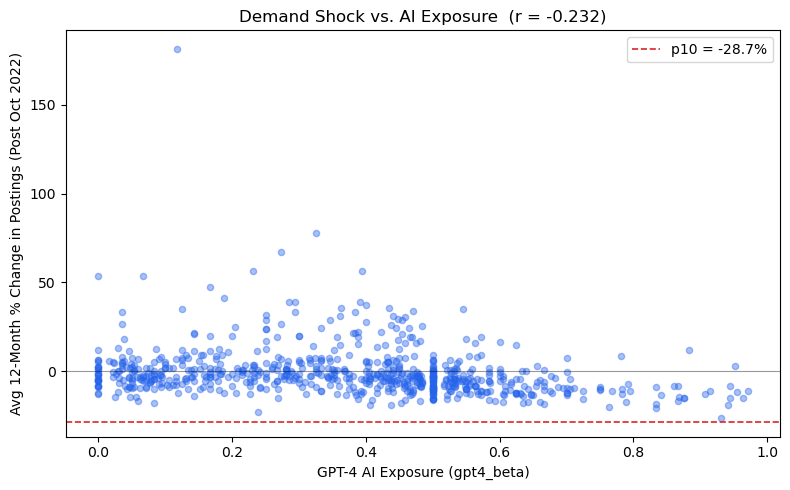

In [82]:
# check correlation between demand shock and AI exposure
ai_exp = pd.read_csv(
    f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/"
    "Shared drives/Insights/Projects/Ongoing/Tulsa STAR Workforce/Input/ai_exposure.csv"
)
ai_exp.columns = ai_exp.columns.str.lower()

# merge on occupation code
shock_ai = post_changes.merge(ai_exp[['occ_code', 'gpt4_beta']], left_on='soc_2021_5', right_on='occ_code', how='inner')

corr = shock_ai[['avg_demand_change_post', 'gpt4_beta']].corr().iloc[0, 1]
print(f'Correlation between avg post-period demand change and GPT-4 exposure: {corr:.3f}')
print()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(shock_ai['gpt4_beta'], shock_ai['avg_demand_change_post'],
           alpha=0.4, s=20, color='#2563eb')
ax.axhline(p10_threshold, color='#dc2626', linestyle='--', linewidth=1.2, label=f'p10 = {p10_threshold:.1f}%')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xlabel('GPT-4 AI Exposure (gpt4_beta)')
ax.set_ylabel('Avg 12-Month % Change in Postings (Post Oct 2022)')
ax.set_title(f'Demand Shock vs. AI Exposure  (r = {corr:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


## Occupations employment level

In [83]:
import glob

# read all BLS OEWS files, keep only detailed occupation rows
data_path = f"/Users/{user}/Documents/USF/ECON696/updated code/data/"
files = sorted(glob.glob(data_path + 'national_M20*_dl.xlsx'))

bls_list = []
for f in files:
    year = int(f.split('national_M')[1][:4])
    df = pd.read_excel(f)
    df.columns = df.columns.str.lower()
    df = df[df['o_group'] == 'detailed'].copy()
    df['year'] = year
    bls_list.append(df)
    print(f'{year}: {len(df):,} detailed occupations')

bls = pd.concat(bls_list, ignore_index=True)
print(f'\nTotal rows: {len(bls):,}')
bls.head()

2019: 789 detailed occupations
2020: 789 detailed occupations
2021: 831 detailed occupations
2022: 830 detailed occupations
2023: 831 detailed occupations
2024: 831 detailed occupations

Total rows: 4,901


,area,area_title,area_type,naics,naics_title,i_group,own_code,occ_code,occ_title,o_group,tot_emp,emp_prse,jobs_1000,loc_quotient,pct_total,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly,year,prim_state,pct_rpt
0,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,detailed,205890,0.8,NaN,NaN,NaN,93.2,193850,0.4,29.95,54.23,88.68,#,#,62290,112790,184460,#,#,NaN,NaN,2019,NaN,NaN
1,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,detailed,2400280,0.3,NaN,NaN,NaN,59.15,123030,0.2,21.66,31.57,48.45,75.69,#,45050,65660,100780,157430,#,NaN,NaN,2019,NaN,NaN
2,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-1031,Legislators,detailed,52280,2.2,NaN,NaN,NaN,*,49440,1.3,*,*,*,*,*,17690,19070,29270,75520,100470,True,NaN,2019,NaN,NaN
3,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-2011,Advertising and Promotions Managers,detailed,25100,3.0,NaN,NaN,NaN,68.22,141890,1.3,29.77,41.51,60.34,84.59,#,61930,86330,125510,175940,#,NaN,NaN,2019,NaN,NaN
4,99,U.S.,1,0,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,detailed,263680,0.8,NaN,NaN,NaN,71.73,149200,0.3,34.14,46.98,65.79,89.1,#,71010,97710,136850,185320,#,NaN,NaN,2019,NaN,NaN


In [84]:
# keep relevant columns and clean tot_emp
emp = (
    bls[['occ_code', 'occ_title', 'year', 'tot_emp']]
    .copy()
    .assign(tot_emp=lambda x: pd.to_numeric(x['tot_emp'], errors='coerce'))
    .dropna(subset=['tot_emp'])
    .sort_values(['occ_code', 'year'])
    .reset_index(drop=True)
)

# year-over-year % change in employment within occupation
emp['emp_yoy'] = emp.groupby('occ_code')['tot_emp'].pct_change() * 100

print(f'Occupations: {emp["occ_code"].nunique()}')
print(f'Years: {sorted(emp["year"].unique())}')
emp.head(12)

Occupations: 861
Years: [2019, 2020, 2021, 2022, 2023, 2024]


,occ_code,occ_title,year,tot_emp,emp_yoy
0,11-1011,Chief Executives,2019,205890.0,NaN
1,11-1011,Chief Executives,2020,202360.0,-1.714508
2,11-1011,Chief Executives,2021,200480.0,-0.929037
3,11-1011,Chief Executives,2022,199240.0,-0.618516
4,11-1011,Chief Executives,2023,211230.0,6.017868
5,11-1011,Chief Executives,2024,211850.0,0.293519
6,11-1021,General and Operations Managers,2019,2400280.0,NaN
7,11-1021,General and Operations Managers,2020,2347420.0,-2.202243
8,11-1021,General and Operations Managers,2021,2984920.0,27.157475
9,11-1021,General and Operations Managers,2022,3376680.0,13.124640


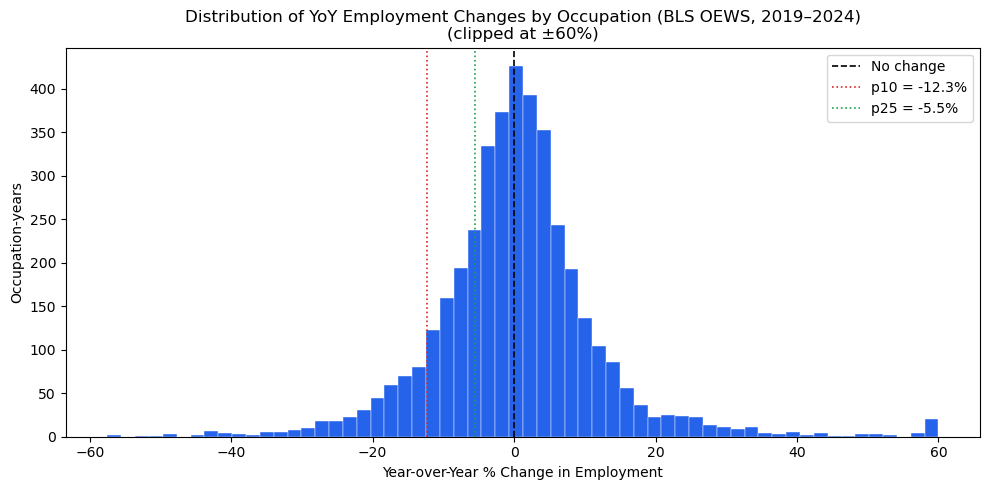

In [85]:
# histogram of year-over-year employment change
fig, ax = plt.subplots(figsize=(10, 5))

data = emp['emp_yoy'].dropna().clip(-60, 60)
ax.hist(data, bins=60, color='#2563eb', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='No change')
ax.axvline(emp['emp_yoy'].quantile(0.10), color='#dc2626', linewidth=1.2, linestyle=':', label=f'p10 = {emp["emp_yoy"].quantile(0.10):.1f}%')
ax.axvline(emp['emp_yoy'].quantile(0.25), color='#16a34a', linewidth=1.2, linestyle=':', label=f'p25 = {emp["emp_yoy"].quantile(0.25):.1f}%')

ax.set_xlabel('Year-over-Year % Change in Employment')
ax.set_ylabel('Occupation-years')
ax.set_title('Distribution of YoY Employment Changes by Occupation (BLS OEWS, 2019–2024)\n(clipped at ±60%)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#For my Capstone project:
#Among AI exposed occs:
# Which are least portable occupations?
# Does portability relate to long term unemployment trends?
# Entry level/ share of postings by AI exposure -> I have this already but do it with new AI exposure



#look at anthropic paper, use different measure for example job postings, how skill portability is part of that
#implications on ai exposed occs